In [48]:
import sklearn.linear_model


In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

data=pd.read_csv("housing.csv")
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [50]:
data.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [51]:
data.describe()
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [52]:
data["median_income"]

0        8.3252
1        8.3014
2        7.2574
3        5.6431
4        3.8462
          ...  
20635    1.5603
20636    2.5568
20637    1.7000
20638    1.8672
20639    2.3886
Name: median_income, Length: 20640, dtype: float64

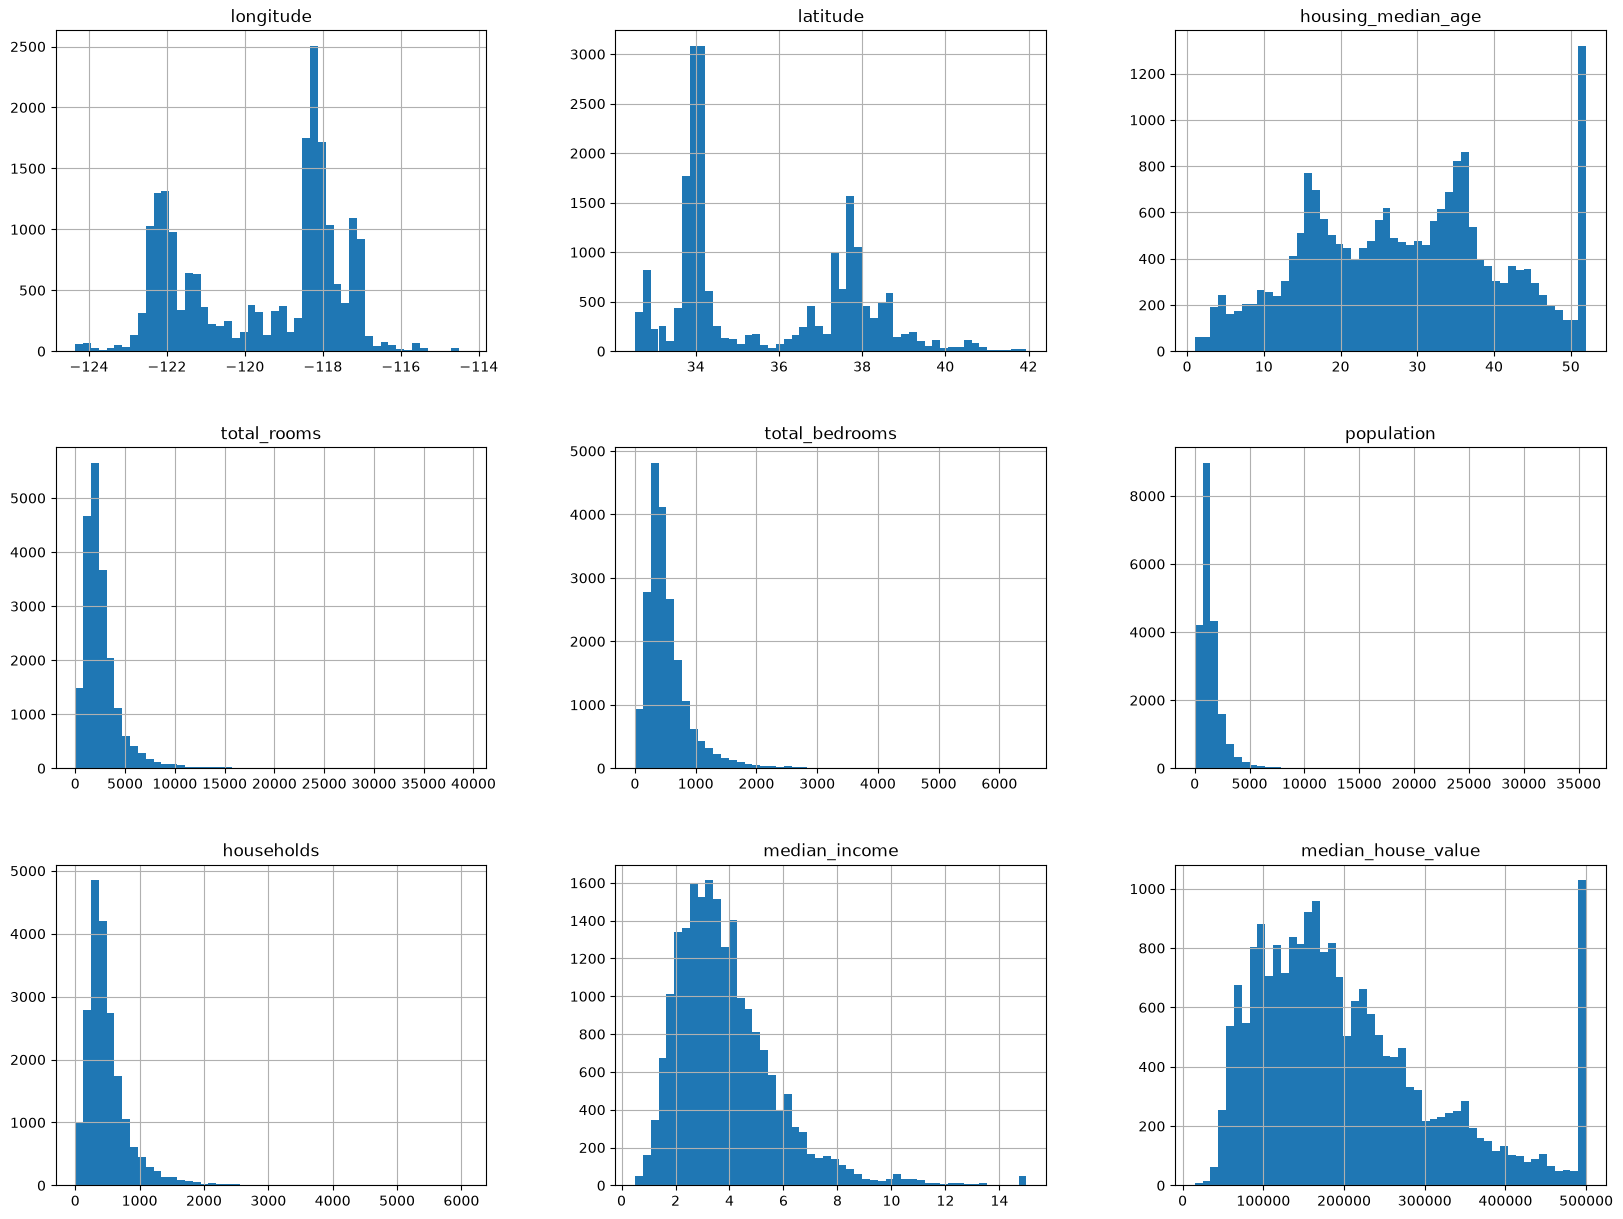

In [53]:
data.hist(bins=50, figsize=(20,15)) # plotting eah numerical attributes with its occurance in y=axis
plt.show()


In [54]:
# creation of test set using a function

def split_train_test(data,test_ratio):
    shuffled_indices=np.random.permutation(len(data))
    test_size=int(len(data)*test_ratio)
    test_indices=shuffled_indices[:test_size]
    train_indices=shuffled_indices[test_size:]
    return data.iloc[train_indices], data.iloc[test_indices]


train_set ,test_set =split_train_test(data,0.2)

print(len(train_set), len(test_set))
print(train_set)

16512 4128
       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
13770    -117.02     34.03                19.0       4415.0           648.0   
6183     -117.91     34.09                20.0       4327.0          1037.0   
16978    -122.30     37.57                36.0       1973.0           352.0   
20226    -119.30     34.29                26.0       3665.0           932.0   
4826     -118.31     34.03                29.0       2438.0           867.0   
...          ...       ...                 ...          ...             ...   
3805     -118.44     34.21                20.0       5756.0          1477.0   
19362    -123.49     38.70                 9.0       5409.0          1019.0   
13251    -117.69     34.11                16.0       2427.0           522.0   
12276    -117.11     33.98                25.0       1254.0           312.0   
7381     -118.25     33.97                32.0        879.0           257.0   

       population  households  median_in

In [55]:
from sklearn.model_selection import train_test_split
Train_set, test_set = train_test_split( data,test_size=0.2,random_state=42)
print(Train_set)
print(test_set)

       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
14196    -117.03     32.71                33.0       3126.0           627.0   
8267     -118.16     33.77                49.0       3382.0           787.0   
17445    -120.48     34.66                 4.0       1897.0           331.0   
14265    -117.11     32.69                36.0       1421.0           367.0   
2271     -119.80     36.78                43.0       2382.0           431.0   
...          ...       ...                 ...          ...             ...   
11284    -117.96     33.78                35.0       1330.0           201.0   
11964    -117.43     34.02                33.0       3084.0           570.0   
5390     -118.38     34.03                36.0       2101.0           569.0   
860      -121.96     37.58                15.0       3575.0           597.0   
15795    -122.42     37.77                52.0       4226.0          1315.0   

       population  households  median_income  media

<Axes: >

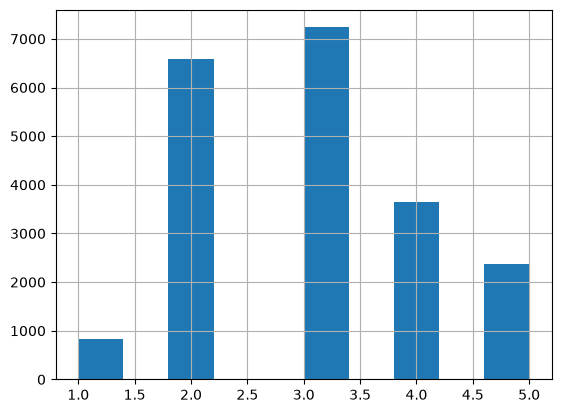

In [56]:
data["income_cat"]=pd.cut(data["median_income"],bins=[0.,1.5,3.0,4.5,6., np.inf], labels=[1,2,3,4,5])
data["income_cat"].hist()



In [57]:
from sklearn.model_selection import StratifiedShuffleSplit

split= StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(data, data["income_cat"]):
    strat_train_set=data.loc[train_index]
    strat_test_set=data.loc[test_index]


for set_  in (strat_train_set,strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)




<Axes: xlabel='longitude', ylabel='latitude'>

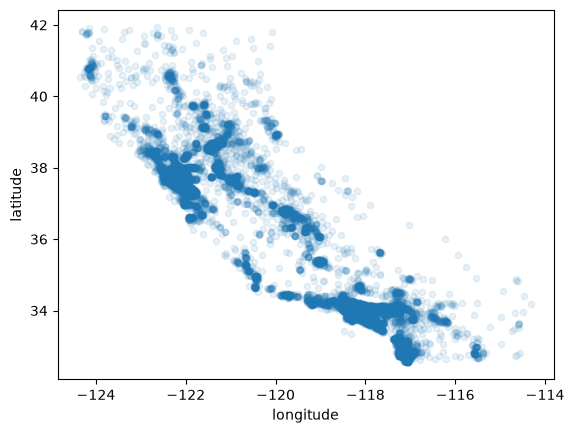

In [58]:
# create a copy of train data while leaves aside a test data
# look the housing distribution

data_train= strat_train_set.copy()
data_train.plot(kind="scatter", x="longitude", y="latitude", alpha=0.1)


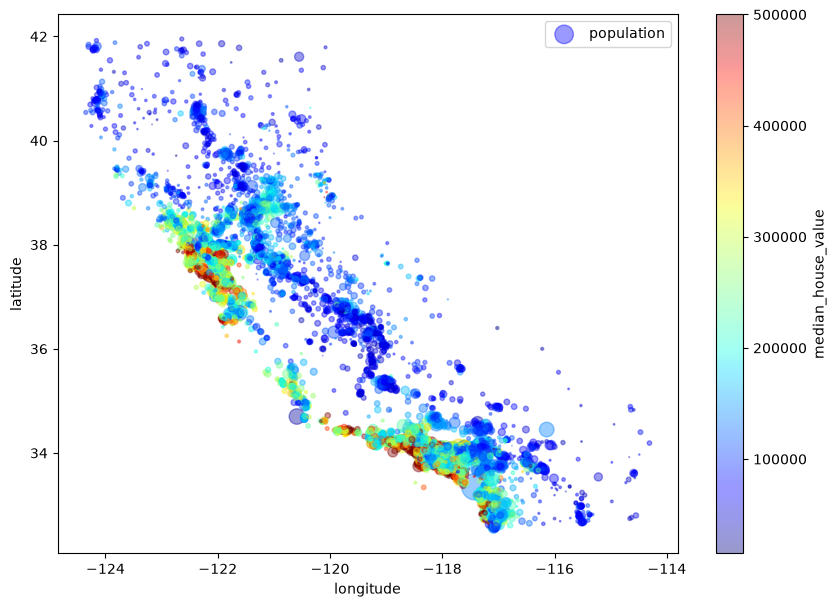

In [59]:
# looking for housing distribution with thier prices

data_train.plot(kind="scatter", x="longitude",y="latitude", alpha=0.4, s=data_train["population"]/100, label="population", figsize=(10,7),c="median_house_value", cmap=plt.get_cmap("jet"), colorbar=True, )
plt.legend()

In [60]:
# we correlate different attributes to see how their related 
corr_matrix=data_train.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.687151
total_rooms           0.135140
housing_median_age    0.114146
households            0.064590
total_bedrooms        0.047781
population           -0.026882
longitude            -0.047466
latitude             -0.142673
Name: median_house_value, dtype: float64

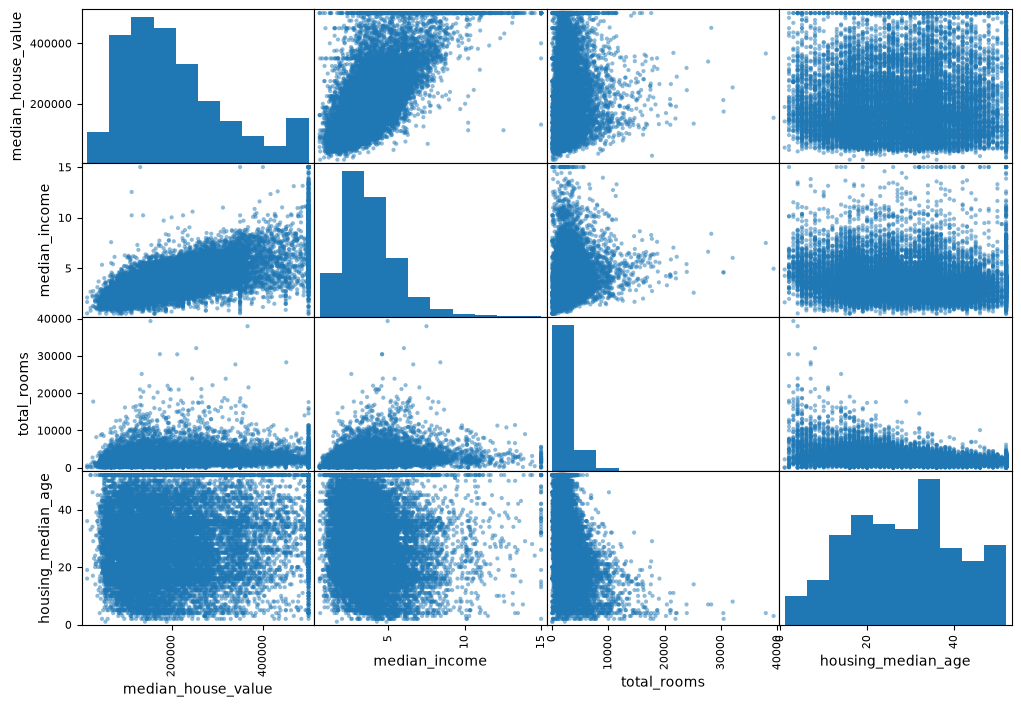

In [61]:
# Another ways of checck correlation is to use pand's scatter matrix by consider few attributes


from pandas.plotting import scatter_matrix
attributes=["median_house_value", "median_income", "total_rooms" ,"housing_median_age"]

scatter_matrix(data_train[attributes], figsize=(12, 8))
plt.show()

<Axes: xlabel='median_income', ylabel='median_house_value'>

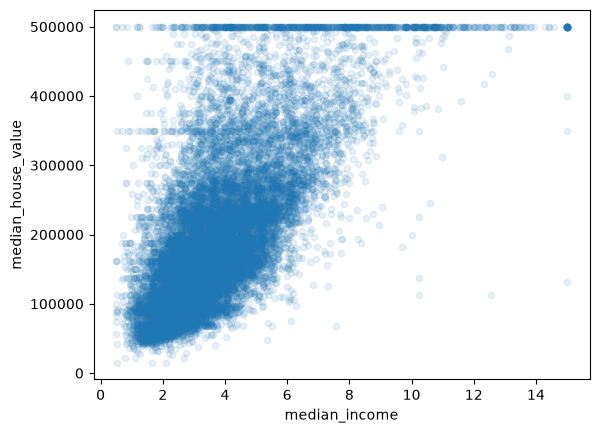

In [62]:
data_train.plot(kind="scatter",x="median_income", y="median_house_value", alpha=0.1)

In [63]:

#combinations of Representatives logical Attributes:

data_train["rooms_per_household"] = data_train["total_rooms"]/data_train["households"]
data_train["bedrooms_per_room"] = data_train["total_bedrooms"]/data_train["total_rooms"]
data_train["population_per_household"]=data_train["population"]/data_train["households"]

corr_matrix=data_train.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value          1.000000
median_income               0.687151
rooms_per_household         0.146255
total_rooms                 0.135140
housing_median_age          0.114146
households                  0.064590
total_bedrooms              0.047781
population_per_household   -0.021991
population                 -0.026882
longitude                  -0.047466
latitude                   -0.142673
bedrooms_per_room          -0.259952
Name: median_house_value, dtype: float64

In [64]:
# Prepare the data for machine learning Algorithms
data=strat_train_set.drop("median_house_value",axis=1)
data_labels=strat_train_set["median_house_value"].copy()
display(data_labels) 



12655     72100.0
15502    279600.0
2908      82700.0
14053    112500.0
20496    238300.0
           ...   
15174    268500.0
12661     90400.0
19263    140400.0
19140    258100.0
19773     62700.0
Name: median_house_value, Length: 16512, dtype: float64

In [65]:
# handle missing value using a sklearn library Imputer
from sklearn.impute import SimpleImputer
imputer=SimpleImputer(strategy="median")

# creat the set with no non numerical attributes

data_num=data.drop("ocean_proximity", axis=1)
imputer.fit(data_num)
X=imputer.transform(data_num)
data_tr=pd.DataFrame(X, columns=data_num.columns)
data_tr.info() # All data have no missing values

<class 'pandas.DataFrame'>
RangeIndex: 16512 entries, 0 to 16511
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16512 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
dtypes: float64(8)
memory usage: 1.0 MB


In [66]:
data_cat=data[["ocean_proximity"]]
data_cat.head(10)

,ocean_proximity
12655,INLAND
15502,NEAR OCEAN
2908,INLAND
14053,NEAR OCEAN
20496,<1H OCEAN
1481,NEAR BAY
18125,<1H OCEAN
5830,<1H OCEAN
17989,<1H OCEAN
4861,<1H OCEAN


In [67]:
# Since the ML algorithms work better with numbers , Lets converts these attributes from text to numbers
from sklearn.preprocessing import OrdinalEncoder
Ordinal_encoder=OrdinalEncoder()
data_cat_encoded=Ordinal_encoder.fit_transform(data_cat)
data_cat_encoded[:50]


array([[1.],
       [4.],
       [1.],
       [4.],
       [0.],
       [3.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [1.],
       [1.],
       [4.],
       [0.],
       [0.],
       [0.],
       [3.],
       [0.],
       [1.],
       [3.],
       [1.],
       [0.],
       [1.],
       [1.],
       [0.],
       [0.],
       [4.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [4.],
       [1.],
       [0.],
       [1.],
       [1.],
       [0.],
       [1.],
       [4.],
       [4.],
       [0.],
       [0.],
       [1.],
       [1.],
       [1.],
       [0.]])

In [68]:
# since the ML algorithms assume number are in order , then it should match with text relations
from sklearn.preprocessing import OneHotEncoder
import numpy as np
cat_encoder=OneHotEncoder()
data_cat_1hot=cat_encoder.fit_transform(data_cat)
cat_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]